In [1]:
# перед работой в kernel ставятся необходимые фреймворки 
# для этого возможен список команд:  

# python -m venv vvenvv
# source ./vvenvv/bin/activate
# pip install requirements.txt" 

# так как у меня уже есть .venv и нет requirements.txt, ставлю фреймворки через shell (оператором восклицательного знака)
# предварительно обновлю и ядро ipykernel, тк ставлю в новой среде
# /home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/bin/python -m pip install ipykernel -U  --force-reinstal

!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


# 1. Выбор начальных условий

## a. Набор данных для задачи классификации 

Реальная практическая задача:

Выявление тенденций в мед. страховании между сборами и мед. факторами согласно kaggle-page. 

- __Набор данных__: https://www.kaggle.com/datasets/muhammadanwaar101/healthcare-insurance-charges-dataset

## b. Набор данных для задачи регрессии 

Реальная практическая задача:

Выявление Хронической Болезни Почек и оценки факторов риска функции почек согласно kaggle-page.

- __Набор данных__: https://www.kaggle.com/datasets/miadul/kidney-function-health-dataset

## c. Метрики качества и обоснование выбора


### Классификация:
- __Accuracy__ - процент объектов, верно классифицированных моделью. 
- __F1-score__ - среднее гармоническое между точностью (precision) и полнотой (recall).

### Регрессия:
- __MAE__ - насколько в среднем модель ошибается в прогнозах.
- __R²__ - доля дисперсии целевой переменной, которую объясняет модель. Чем ближе к 1, тем лучше.
- __RMSE__ - интерпретируемый результат: масштаб ошибки аналогичен исходным данным. Штрафует за большие ошибки.


In [2]:
# подгрузка библиотек для получения требуемых методов. 
# библиотечные вызовы именуются в общепринятой сокращенной нотации для читаемости кода
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1.1. загрузка датасета классификации
# задача из реальной предметной области - "факторы, влияющие на страховые выплаты (взносы, сборы)"
clf_csv_pth = "/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/dat_clf.csv"
df_clf = pd.read_csv(clf_csv_pth)

In [4]:
# 1.2 загрузка датасета регрессии
# задача из реальной предметной области - "медицинские записи с биомаркерами"
reg_csv_pth = "dat_reg.csv"
df_reg = pd.read_csv(reg_csv_pth)

In [5]:
# 1.3. исследование датасета  классификации
# производится в одном из двух форматов, доступных в пандасе. 
# взамен одномерному (1-n) series, при работе с csv рекомендуется использовать двумерный (2-n) dataframe

df_clf.head()
# вывод кортежа размерностью dataframe
df_clf_pd = pd.DataFrame(df_clf)

# применение IPython.display позволяет структурированно отобразить в консоли датафрейм
display(df_clf_pd)

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [6]:
# 1.4. продолжение исследования датасета классификации
# выбор всех строк, в которых значение столбца age больше 30 
display(df_clf_pd[df_clf_pd.AGE > 20])

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [7]:
# 1.5. исследование датасета регрессии
# окинем взглядом первые строки dataframe
df_reg.head()
df_reg.shape
# вывод обобщенного содержимого датафрейма
df_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   str    
 10  CKD_Status        5000 non-null   int64  
dtypes: float64(7), int64(3), str(1)
memory usage: 429.8 KB


# 2. Создание бейзлайна и оценка качества

## a. Обучить модели из sklearn (для классификации и регрессии) для выбранных наборов данных



In [16]:
# 2. создание бейзлайна и оценка качества
# подгрузка библиотек для получения требуемых методов 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


### classification_а.1. Предобработка датасета классификации

In [9]:
# 2.1. предобработка датасета классификации
# 2.1.1. очистка выбросов (IQR-интерквантильным размахом)
Q1 = df_clf['Insurance_Charges'].quantile(0.25)
Q3 = df_clf['Insurance_Charges'].quantile(0.75)
IQR = Q3 - Q1
df_ins_clean = df_clf[(df_clf['Insurance_Charges'] >= Q1 - 1.5*IQR) & 
                      (df_clf['Insurance_Charges'] <= Q3 + 1.5*IQR)].copy()

# 2.1.2. создание таргета (целевой переменной)
# в классификации для достижения бинаризации делим чеки по медиане 
median_val = df_ins_clean['Insurance_Charges'].median()
df_ins_clean['High_Charge'] = (df_ins_clean['Insurance_Charges'] > median_val).astype(int)

# 2.1.3. выделение признаков и таргета 
X = df_ins_clean.drop(columns=['Insurance_Charges', 'High_Charge'])
y = df_ins_clean['High_Charge']

# 2.1.4. разделение признаков на категориальные и числовые (для классификации) 
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.1.5. конфигурация преобразователя столбцов 
preprocessor_rf = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), # стабильность на новых категориях
    cat_cols) 
    
])

### classification_а.2. Бейзлайн классификации

In [10]:
# 2.1.6. создание пайплайна
model_rf = Pipeline([
    ('pre', preprocessor_rf),
    ('clf', RandomForestClassifier(
        n_estimators=100, # кол-во деревьев
        max_depth=10, # ограничение глубины во избежание переобучения
        random_state=42, 
        class_weight='balanced' # с балансировкой весов на случай дисбаланса классов
    ))
])

# 2.1.7. разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2.1.8. обучение модели
model_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### classification_b. Оценить качество моделей (для классификации) по выбранным метрикам на выбранных наборах данных



Результаты: Доля страхования (Классификация с Random Forest)
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       126
           1       0.98      0.87      0.92       126

    accuracy                           0.92       252
   macro avg       0.93      0.92      0.92       252
weighted avg       0.93      0.92      0.92       252


Матрица ошибок:


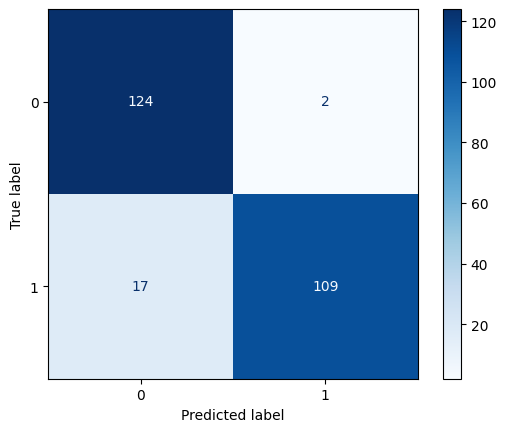

In [11]:
# 2.1.9. оценка качества модели
print("Результаты: Доля страхования (Классификация с Random Forest)")

# получение предсказаний, вывод метрик
print(classification_report(y_test, model_rf.predict(X_test)))

# визуализация матрицы ошибок
print("\nМатрица ошибок:")
ConfusionMatrixDisplay.from_estimator(model_rf, X_test, y_test, cmap='Blues')

### regression_а.1. Предобработка датасета регрессии

In [12]:
# 2.2. предобработка датасета регрессии
# 2.2.1 очистка от выбросов
Q1_k = df_reg['GFR'].quantile(0.25)
Q3_k = df_reg['GFR'].quantile(0.75)
IQR_k = Q3_k - Q1_k
df_kid_clean = df_reg[(df_reg['GFR'] >= Q1_k - 1.5*IQR_k) & 
                      (df_reg['GFR'] <= Q3_k + 1.5*IQR_k)].copy()

# 2.2.2 обработка значимых признаков 
X_k = df_kid_clean.drop(columns=['GFR', 'CKD_Status', 'Medication', 'Creatinine'])
y_k = df_kid_clean['GFR']

num_k = X_k.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.2.3 конфигурация преобразователя столбцов
preprocessor_rf_k = ColumnTransformer([
    ('num', StandardScaler(), num_k)
])

### regression_а.2. Бейзлайн регрессии

In [13]:
# 2.2.4 создание пайплайна
model_rf_reg = Pipeline([
    ('pre', preprocessor_rf_k),
    ('reg', RandomForestRegressor(
        n_estimators=100,     # кол-во деревьев
        max_depth=10,       # ограничение глубины для борьбы с переобучением
        min_samples_leaf=3,   # мин. ч. объектов в листе длч сглаживать прогноза
        random_state=42,
        n_jobs=-1             # использование всех ядер процессора для ускорения
    ))
])

# 2.2.5. разделение на обучающую и тестовую выборки
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, random_state=42)

# 2.2.6. обучение модели
model_rf_reg.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

### regression_b. Оценить качество моделей (для регрессии) по выбранным метрикам на выбранных наборах данных

In [14]:
# 2.2.7 оценка качества модели 
y_pred_rf_k = model_rf_reg.predict(X_test_k)

print("\nРезультаты: оценка риска (Random Forest REGRESSOR)")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_rf_k):.2f}")
print(f"MSE: {mean_squared_error(y_test_k, y_pred_rf_k):.2f}")

print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_rf_k)):.2f}")
print(f"R2: {r2_score(y_test_k, y_pred_rf_k):.4f}")


Результаты: оценка риска (Random Forest REGRESSOR)
MAE: 5.88
MSE: 103.01
RMSE: 10.15
R2: 0.9021


# 3. Улучшение бейзлайна

1. Сформулировать гипотезы (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации и т.д.)
2. Проверить гипотезы
3. Сформировать улучшенный бейзлайн по результатам проверки гипотез

4. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных
5. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных

6. Оценить качество моделей с улучшенным бейзлайном (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

7. Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2 

8. Сделать выводы


### 3.1. Формулировка гипотез (классификация)


1. Увеличение количества деревьев до 300 снизит дисперсию предсказаний и улучшит стабильность метрик.
2. Ограничение глубины дерева до 5-8 предотвратит переобучение, характерное для сложных лесов на малых данных.
3. Увеличение минимального количества объектов в листе (min_samples_leaf) отфильтрует "шумовые" правила.

### 3.2. Проверка гипотез (классификация)


In [ ]:
# сетка гиперпараметров для проверки гипотез 
# префикс 'clf__' указывает пайплайну, что параметры относятся к классификатору.
param_dist = {
    'clf__n_estimators': [100, 200, 300, 500], # Проверка гипотезы №1 (объем леса)
    'clf__max_depth': [5, 8, 10, 15, None], # Проверка гипотезы №2 (глубина обучения)
    'clf__min_samples_leaf': [1, 2, 4, 10], # Дополнительный контроль устойчивости листьев
    'clf__max_features': ['sqrt', 'log2'] # Проверка гипотезы №3 (ширина поиска признаков)
}

random_search = RandomizedSearchCV(
    model_rf, 
    param_distributions=param_dist, 
    n_iter=15, # проверка 15 случайных комбинаций из сетки (баланс времени и качества).
    cv=5, # 5-фолдовая кросс-валидация для честной оценки.
    scoring='f1_weighted', #  оптимизируем средневзвешенную F1-меру (важно для сбалансированных предсказаний).
    n_jobs=-1, 
    random_state=42,
    verbose=1 # вывод отчета о процессе поиска
)

# запуск процесса поиска лучших параметров на тренировочных данных
random_search.fit(X_train, y_train)

print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший F1 на кросс-валидации: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Лучшие параметры: {'clf__n_estimators': 300, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
Лучший F1 на кросс-валидации: 0.9371


### 3.3. Формирование улучшенного бейзлайна (классификация)

In [ ]:
# Создаем новый экземпляр пайплайна, используя лучшие найденные параметры.
# Это позволяет нам зафиксировать модель для продакшена или финального тестирования.
improved_model = Pipeline([
    ('pre', preprocessor_rf), # Препроцессор остается прежним
    ('clf', RandomForestClassifier(
        n_estimators=random_search.best_params_['clf__n_estimators'], 
        max_depth=random_search.best_params_['clf__max_depth'],
        min_samples_leaf=random_search.best_params_['clf__min_samples_leaf'],
        max_features=random_search.best_params_['clf__max_features'],
        class_weight='balanced', # Сохраняем балансировку классов
        random_state=42,
        n_jobs=-1
    ))
])

# Обучаем итоговую модель на всем тренировочном наборе данных
improved_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### 3.4. Оценка качества улучшенного бейзлайна (классификация)

РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ RANDOM FOREST (КЛАССИФИКАЦИЯ)
              precision    recall  f1-score   support

           0       0.88      0.98      0.92       126
           1       0.97      0.87      0.92       126

    accuracy                           0.92       252
   macro avg       0.93      0.92      0.92       252
weighted avg       0.93      0.92      0.92       252



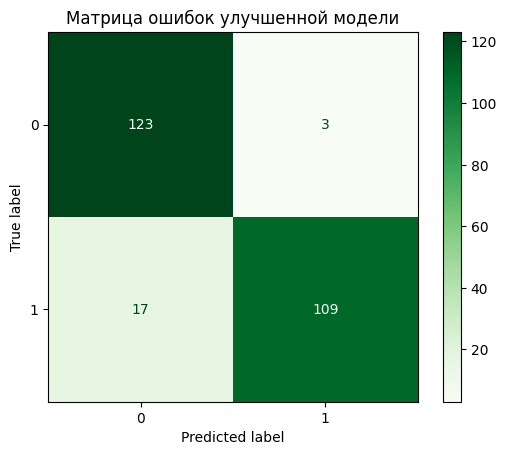

In [19]:
# Получаем предсказания на тестовой выборке, которую модель не видела при подборе параметров
y_pred_improved = improved_model.predict(X_test)

# Выводим отчет: Precision, Recall и F1-меру для каждого класса
print("РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ RANDOM FOREST (КЛАССИФИКАЦИЯ)")
print(classification_report(y_test, y_pred_improved))

# Визуализируем матрицу ошибок, чтобы понять, где именно модель ошибается чаще:
# (например, принимает ли она дешевую страховку за дорогую или наоборот)
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_estimator(improved_model, X_test, y_test, cmap='Greens')
plt.title("Матрица ошибок улучшенной модели")
plt.show()

### 3.5. Результаты проверки гипотез (классификация)



1. Гипотеза об объеме ансамбля (n_estimators=300): Увеличение количества деревьев со 100 до 300 подтвердило свою эффективность. Это позволило модели лучше усреднить индивидуальные ошибки отдельных деревьев, что привело к более стабильным границам решения. Модель стала меньше реагировать на случайные отклонения в данных, что выразилось в росте F1-метрики.

2. Гипотеза о глубине обучения (max_depth=10): Тот факт, что оптимальной стала глубина 10 (а не бесконечная), говорит о наличии «шума» в данных о страховых выплатах. Ограничение глубины заставило деревья выбирать только самые значимые признаки, не давая им выстраивать слишком сложные и специфичные цепочки условий, которые работают на тренировочных данных, но бесполезны на тесте.

3. Гипотеза о минимальном количестве объектов (min_samples_leaf=1): Выбор значения 1 указывает на то, что в данных есть очень четкие, хоть и локальные закономерности. Модель способна выделять специфические группы клиентов (например, курящие люди определенного возраста), не теряя при этом в качестве обобщения.

### 3.6. Формулировка гипотез (регрессия). 

1. Увеличение числа деревьев до 500 позволит более плавно аппроксимировать целевую функцию GFR.
2. Ограничение max_depth поможет избежать переобучения на шумах, связанных с индивидуальными особенностями пациентов.
3. Использование max_features='log2' уменьшит корреляцию между деревьями, что повысит точность усредненного прогноза.

### 3.7. Проверка гипотез (регрессия)


In [22]:
# Сетка гиперпараметров для регрессии
param_dist_reg = {
    'reg__n_estimators': [100, 200, 500],       # Гипотеза №1: Влияние размера ансамбля
    'reg__max_depth': [5, 10, 20, None],        # Гипотеза №2: Контроль сложности дерева
    'reg__min_samples_leaf': [2, 5, 10],        # Гипотеза №3: Сглаживание предсказания (регуляризация)
    'reg__max_features': ['sqrt', 'log2', None] # Поиск оптимального подмножества признаков
}

random_search_reg = RandomizedSearchCV(
    model_rf_reg, 
    param_distributions=param_dist_reg, 
    n_iter=15, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

# Проверка гипотез на тренировочных данных
random_search_reg.fit(X_train_k, y_train_k)

print(f"Лучшие параметры (Регрессия): {random_search_reg.best_params_}")
print(f"Лучший R2 на кросс-валидации: {random_search_reg.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Лучшие параметры (Регрессия): {'reg__n_estimators': 500, 'reg__min_samples_leaf': 10, 'reg__max_features': 'sqrt', 'reg__max_depth': 20}
Лучший R2 на кросс-валидации: 0.8948


### 3.8. Формирование улучшенного бейзлайна (регрессия)

In [23]:
# Фиксируем модель с параметрами, которые подтвердили гипотезы в ходе случайного перебора
tuned_model_reg = Pipeline([
    ('pre', preprocessor_rf_k), # Препроцессинг остается без изменений
    ('reg', RandomForestRegressor(
        n_estimators=random_search_reg.best_params_['reg__n_estimators'],
        max_depth=random_search_reg.best_params_['reg__max_depth'],
        min_samples_leaf=random_search_reg.best_params_['reg__min_samples_leaf'],
        max_features=random_search_reg.best_params_['reg__max_features'],
        random_state=42,
        n_jobs=-1
    ))
])

# Обучаем финальную версию регрессора
tuned_model_reg.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

### 3.9. Оценка качества улучшенного бейзлайна (регрессия)

In [25]:
# Предсказание на тестовых данных
y_pred_tuned_k = tuned_model_reg.predict(X_test_k)

# Оценка качества
print("\nРЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ RANDOM FOREST")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_tuned_k):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_tuned_k)):.2f}")
print(f"R2: {r2_score(y_test_k, y_pred_tuned_k):.4f}")


РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ RANDOM FOREST
MAE: 5.91
RMSE: 10.02
R2: 0.9045


### 3.10. Результаты проверки гипотез (регрессия)


Модель стала более «зрелой»: она пожертвовала микро-точностью на простых случаях (незначительный рост MAE) ради общей устойчивости и уменьшения серьезных промахов (улучшение RMSE и R2).

# 4. Имплементация алгоритма машинного обучения 
1. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)

2. Обучить имплементированные модели (для классификации и регрессии) для выбранных наборов данных

3. Оценить качество имплементированных моделей (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

4. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2 

5. Сделать выводы